In [1]:

# Analysis Plan for Research Hypothesis r18 - Vector Sum Model for Composite Coherence

print("="*80)
print("ANALYSIS PLAN: Vector Sum Model for Composite Coherence")
print("="*80)
print()
print("Research Hypothesis:")
print("A simple vector sum model using the theoretical adjacent-fiber law")
print("(|S_{k+1}|/|S_k| ≈ C·loglog(N)/k) and empirically measured phases")
print("can accurately predict the total sum D_F and composite coherence R_comp")
print("for both ζ(s) and its perturbed variants like F_k2.")
print()
print("="*80)
print("STEP-BY-STEP ANALYSIS PLAN")
print("="*80)
print()
print("1. DATA GENERATION & COMPUTATION")
print(" - Implement Riemann zeta partial sum D_ζ(t*; N) with Kahan summation")
print(" - At N=10^5 and resonance peak t* = 2818.99 (from r18)")
print(" - Compute complex sums S_k for k=1 to 5, where:")
print(" S_k = Σ_{n≤N, ω(n)=k} n^{-1/2-it*}")
print(" - Implement perturbed function F_k2: a_n = -1 for ω(n)=2")
print()
print("2. EMPIRICAL MODEL PARAMETER ESTIMATION")
print(" a. Base vector: Extract S_1 (primes contribution)")
print(" b. Magnitude scaling law:")
print(" - Compute ratios |S_{k+1}|/|S_k| for k=1,2,3,4")
print(" - Fit to model: ratio = C·loglog(N)/k")
print(" - Extract constant C via regression")
print(" c. Phase rotation law:")
print(" - Compute phase differences: Δθ_k = arg(S_{k+1}) - arg(S_k)")
print(" - Characterize phase shifts")
print()
print("3. BUILD PREDICTIVE MODEL")
print(" - Input: S_1 (base vector) and N")
print(" - Output: Predicted S_2, S_3, S_4, S_5")
print(" - Method: Apply fitted scaling law and phase rotations")
print()
print("4. MODEL VALIDATION")
print(" a. For ζ(s):")
print(" - Predict: D_pred = Σ S_k (k=1 to 5)")
print(" - Compute R_comp from predicted vectors")
print(" - Compare to actual measured values")
print(" b. For F_k2 (perturbed):")
print(" - Apply model with S_2 flipped 180°")
print(" - Predict total sum and R_comp")
print(" - Compare to actual F_k2 measurements")
print()
print("5. QUANTITATIVE ASSESSMENT")
print(" - Compute prediction errors (relative and absolute)")
print(" - Assess model fidelity for both magnitude and phase")
print(" - Statistical comparison of predicted vs observed")
print()
print("="*80)
print("EXPECTED DELIVERABLES")
print("="*80)
print("1. Measured S_k vectors for ζ at t*=2818.99, N=10^5")
print("2. Fitted parameters: C (scaling), Δθ_k (phase shifts)")
print("3. Predictive model function")
print("4. Comparison tables: predicted vs actual for ζ and F_k2")
print("5. R_comp predictions vs measurements")
print("6. Final figure summarizing model performance")
print()
print("="*80)


ANALYSIS PLAN: Vector Sum Model for Composite Coherence

Research Hypothesis:
A simple vector sum model using the theoretical adjacent-fiber law
(|S_{k+1}|/|S_k| ≈ C·loglog(N)/k) and empirically measured phases
can accurately predict the total sum D_F and composite coherence R_comp
for both ζ(s) and its perturbed variants like F_k2.

STEP-BY-STEP ANALYSIS PLAN

1. DATA GENERATION & COMPUTATION
 - Implement Riemann zeta partial sum D_ζ(t*; N) with Kahan summation
 - At N=10^5 and resonance peak t* = 2818.99 (from r18)
 - Compute complex sums S_k for k=1 to 5, where:
 S_k = Σ_{n≤N, ω(n)=k} n^{-1/2-it*}
 - Implement perturbed function F_k2: a_n = -1 for ω(n)=2

2. EMPIRICAL MODEL PARAMETER ESTIMATION
 a. Base vector: Extract S_1 (primes contribution)
 b. Magnitude scaling law:
 - Compute ratios |S_{k+1}|/|S_k| for k=1,2,3,4
 - Fit to model: ratio = C·loglog(N)/k
 - Extract constant C via regression
 c. Phase rotation law:
 - Compute phase differences: Δθ_k = arg(S_{k+1}) - arg(S_k)
 - Cha

In [2]:

import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("Imported libraries successfully")
print(f"NumPy version: {np.__version__}")


Imported libraries successfully
NumPy version: 1.26.4


In [3]:

# Step 1: Implement prime sieve and omega function
@njit
def sieve_of_eratosthenes(limit):
 """Generate primes up to limit using Sieve of Eratosthenes"""
 is_prime = np.ones(limit + 1, dtype=np.bool_)
 is_prime[0] = is_prime[1] = False
 
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 for j in range(i*i, limit + 1, i):
 is_prime[j] = False
 
 primes = np.where(is_prime)[0]
 return primes

def compute_omega(N):
 """
 Compute omega(n) = number of distinct prime factors for all n <= N
 Using optimized factorization
 """
 omega = np.zeros(N + 1, dtype=np.int32)
 
 # For each prime, mark all its multiples
 for p in range(2, N + 1):
 if omega[p] == 0: # p is prime
 for multiple in range(p, N + 1, p):
 omega[multiple] += 1
 
 return omega

print("Computing primes and omega values for N=10^5...")
N = 100000
primes = sieve_of_eratosthenes(N)
omega = compute_omega(N)

print(f"Number of primes up to {N}: {len(primes)}")
print(f"First 10 primes: {primes[:10]}")
print(f"Omega values for n=1 to 20: {omega[1:21]}")
print(f"Number of n with omega(n)=1 (primes): {np.sum(omega == 1)}")
print(f"Number of n with omega(n)=2: {np.sum(omega == 2)}")
print(f"Number of n with omega(n)=3: {np.sum(omega == 3)}")
print(f"Number of n with omega(n)=4: {np.sum(omega == 4)}")
print(f"Number of n with omega(n)=5: {np.sum(omega == 5)}")


Computing primes and omega values for N=10^5...


Number of primes up to 100000: 9592
First 10 primes: [ 2 3 5 7 11 13 17 19 23 29]
Omega values for n=1 to 20: [0 1 1 1 1 2 1 1 1 2 1 2 1 2 2 1 1 2 1 2]
Number of n with omega(n)=1 (primes): 9700
Number of n with omega(n)=2: 33759
Number of n with omega(n)=3: 38844
Number of n with omega(n)=4: 15855
Number of n with omega(n)=5: 1816


In [4]:

# Step 2: Implement Kahan compensated summation for complex numbers
@njit
def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex array
 """
 s = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for val in values:
 y = val - c
 t = s + y
 c = (t - s) - y
 s = t
 
 return s

def compute_S_k_vectorized(t_star, N, omega_vals, k_max=5):
 """
 Compute S_k = Σ_{n≤N, ω(n)=k} n^{-1/2-it*} for k=1 to k_max
 Using Kahan compensated summation
 
 Parameters:
 -----------
 t_star : float
 Height on critical line
 N : int
 Truncation depth
 omega_vals : ndarray
 Precomputed omega(n) values
 k_max : int
 Maximum k value
 
 Returns:
 --------
 S_k_dict : dict
 Dictionary mapping k to complex S_k value
 """
 S_k_dict = {}
 
 for k in range(1, k_max + 1):
 # Find all n with omega(n) = k
 indices = np.where(omega_vals[1:N+1] == k)[0] + 1 # +1 because omega_vals[0] is for n=0
 
 if len(indices) == 0:
 S_k_dict[k] = 0.0 + 0.0j
 continue
 
 # Compute contributions: n^{-1/2-it*} = n^{-1/2} * n^{-it*}
 # n^{-it*} = exp(-it* log n) = cos(t* log n) - i sin(t* log n)
 n_vals = indices.astype(np.float64)
 log_n = np.log(n_vals)
 
 # Real part: n^{-1/2} * cos(-t* log n)
 # Imag part: n^{-1/2} * sin(-t* log n)
 magnitude = 1.0 / np.sqrt(n_vals)
 phase = -t_star * log_n
 
 contributions = magnitude * (np.cos(phase) + 1j * np.sin(phase))
 
 # Use Kahan summation
 S_k = kahan_sum_complex(contributions)
 S_k_dict[k] = S_k
 
 return S_k_dict

# Test at the resonance peak t* = 2818.99
t_star = 2818.99
print(f"Computing S_k vectors at t* = {t_star}, N = {N}")
print("Using Kahan compensated summation...")

S_k_zeta = compute_S_k_vectorized(t_star, N, omega, k_max=5)

print("\nResults for ζ(s) at resonance peak:")
print("="*60)
for k in range(1, 6):
 S = S_k_zeta[k]
 mag = np.abs(S)
 phase = np.angle(S)
 print(f"k={k}: S_{k} = {S.real:10.6f} + {S.imag:10.6f}i")
 print(f" |S_{k}| = {mag:10.6f}, arg(S_{k}) = {phase:10.6f} rad ({np.degrees(phase):8.3f}°)")
 print()


Computing S_k vectors at t* = 2818.99, N = 100000
Using Kahan compensated summation...

Results for ζ(s) at resonance peak:
k=1: S_1 = 3.634840 + 0.977057i
 |S_1| = 3.763868, arg(S_1) = 0.262596 rad ( 15.046°)

k=2: S_2 = 3.317886 + 2.298914i
 |S_2| = 4.036505, arg(S_2) = 0.605935 rad ( 34.718°)

k=3: S_3 = 1.916857 + 2.267411i
 |S_3| = 2.969090, arg(S_3) = 0.868982 rad ( 49.789°)

k=4: S_4 = 1.045059 + 0.433579i
 |S_4| = 1.131432, arg(S_4) = 0.393272 rad ( 22.533°)

k=5: S_5 = -0.093519 + 0.324888i
 |S_5| = 0.338080, arg(S_5) = 1.851070 rad ( 106.059°)



In [5]:

# Step 3: Compute total sum and verify
D_total_measured = sum(S_k_zeta.values())
print("Measured total sum for ζ(s):")
print(f"D_ζ(t*; N) = Σ S_k = {D_total_measured.real:.6f} + {D_total_measured.imag:.6f}i")
print(f"|D_ζ| = {np.abs(D_total_measured):.6f}")
print(f"arg(D_ζ) = {np.angle(D_total_measured):.6f} rad ({np.degrees(np.angle(D_total_measured)):.3f}°)")
print()

# Compute R_comp using the definition from the literature
# R_comp based on composite coherence (ω ≥ 2)
def compute_R_comp(S_k_dict, k_min=2, k_max=5):
 """
 Compute composite coherence R_comp
 Following the normalization used in the previous analyses
 """
 # Sum over composite classes (k >= 2)
 S_composite = sum([S_k_dict[k] for k in range(k_min, k_max + 1)])
 
 # Sum of magnitudes
 sum_mags = sum([np.abs(S_k_dict[k]) for k in range(k_min, k_max + 1)])
 
 # Mean resultant length (normalized coherence)
 if sum_mags > 0:
 R_comp = np.abs(S_composite) / sum_mags
 else:
 R_comp = 0.0
 
 return R_comp

R_comp_measured = compute_R_comp(S_k_zeta, k_min=2, k_max=5)
print(f"Measured R_comp (composite coherence, k=2-5): {R_comp_measured:.6f}")
print()

# Also compute the total coherence including primes
R_total = np.abs(D_total_measured) / sum([np.abs(S_k_zeta[k]) for k in range(1, 6)])
print(f"Total coherence (all k=1-5): {R_total:.6f}")


Measured total sum for ζ(s):
D_ζ(t*; N) = Σ S_k = 9.821122 + 6.301849i
|D_ζ| = 11.669093
arg(D_ζ) = 0.570492 rad (32.687°)

Measured R_comp (composite coherence, k=2-5): 0.963094

Total coherence (all k=1-5): 0.953437


In [6]:

# Step 4: Empirical parameter estimation
# a. Extract magnitude ratios
print("="*80)
print("EMPIRICAL PARAMETER ESTIMATION")
print("="*80)
print()

magnitudes = [np.abs(S_k_zeta[k]) for k in range(1, 6)]
print("Magnitudes |S_k|:")
for k in range(1, 6):
 print(f"|S_{k}| = {magnitudes[k-1]:.6f}")
print()

# Compute ratios |S_{k+1}|/|S_k|
ratios = []
for k in range(1, 5):
 ratio = magnitudes[k] / magnitudes[k-1]
 ratios.append(ratio)
 print(f"|S_{k+1}|/|S_{k}| = {ratio:.6f} (k={k})")
print()

# b. Fit the theoretical model: |S_{k+1}|/|S_k| = C·loglog(N)/k
# loglog(N) for N=10^5
loglog_N = np.log(np.log(N))
print(f"loglog(N) = loglog(10^5) = {loglog_N:.6f}")
print()

# Expected ratios from theory: C·loglog(N)/k
k_values = np.array([1, 2, 3, 4])
theoretical_form = loglog_N / k_values

print("Theoretical form (before scaling): loglog(N)/k:")
for i, k in enumerate(k_values):
 print(f"k={k}: {theoretical_form[i]:.6f}")
print()

# Fit to find C
# ratio[k-1] = C * loglog(N) / k
# We use least squares: minimize sum of (ratio[k-1] - C*loglog(N)/k)^2

from scipy.optimize import minimize_scalar

def fit_scaling_constant(ratios, k_values, loglog_N):
 """Fit C in the model ratio = C * loglog(N) / k"""
 
 def residual(C):
 predicted = C * loglog_N / k_values
 return np.sum((np.array(ratios) - predicted)**2)
 
 result = minimize_scalar(residual, bounds=(0.1, 10.0), method='bounded')
 C_opt = result.x
 
 return C_opt

C_fitted = fit_scaling_constant(ratios, k_values, loglog_N)
print(f"Fitted scaling constant C = {C_fitted:.6f}")
print()

# Check fit quality
print("Comparison of measured vs predicted ratios:")
print("k Measured Predicted (C·loglog(N)/k) Error")
print("-" * 60)
for i, k in enumerate(k_values):
 predicted = C_fitted * loglog_N / k
 error = ratios[i] - predicted
 rel_error = error / ratios[i] * 100
 print(f"{k} {ratios[i]:.6f} {predicted:.6f} {error:+.6f} ({rel_error:+.2f}%)")


EMPIRICAL PARAMETER ESTIMATION

Magnitudes |S_k|:
|S_1| = 3.763868
|S_2| = 4.036505
|S_3| = 2.969090
|S_4| = 1.131432
|S_5| = 0.338080

|S_2|/|S_1| = 1.072435 (k=1)
|S_3|/|S_2| = 0.735560 (k=2)
|S_4|/|S_3| = 0.381070 (k=3)
|S_5|/|S_4| = 0.298807 (k=4)

loglog(N) = loglog(10^5) = 2.443470

Theoretical form (before scaling): loglog(N)/k:
k=1: 2.443470
k=2: 1.221735
k=3: 0.814490
k=4: 0.610868

Fitted scaling constant C = 0.472018

Comparison of measured vs predicted ratios:
k Measured Predicted (C·loglog(N)/k) Error
------------------------------------------------------------
1 1.072435 1.153363 -0.080928 (-7.55%)
2 0.735560 0.576681 +0.158878 (+21.60%)
3 0.381070 0.384454 -0.003384 (-0.89%)
4 0.298807 0.288341 +0.010466 (+3.50%)


In [7]:

# Step 5: Phase analysis - compute phase differences
print("="*80)
print("PHASE ROTATION ANALYSIS")
print("="*80)
print()

phases = [np.angle(S_k_zeta[k]) for k in range(1, 6)]
print("Phases arg(S_k) [radians]:")
for k in range(1, 6):
 phase_deg = np.degrees(phases[k-1])
 print(f"arg(S_{k}) = {phases[k-1]:10.6f} rad = {phase_deg:8.3f}°")
print()

# Compute phase differences Δθ_k = arg(S_{k+1}) - arg(S_k)
delta_theta = []
print("Phase differences Δθ_k = arg(S_{k+1}) - arg(S_k):")
for k in range(1, 5):
 delta = phases[k] - phases[k-1]
 delta_theta.append(delta)
 delta_deg = np.degrees(delta)
 print(f"Δθ_{k} = arg(S_{k+1}) - arg(S_{k}) = {delta:10.6f} rad = {delta_deg:8.3f}°")
print()

# Compute mean phase rotation
mean_delta_theta = np.mean(delta_theta)
std_delta_theta = np.std(delta_theta)
print(f"Mean phase rotation: {mean_delta_theta:.6f} rad = {np.degrees(mean_delta_theta):.3f}°")
print(f"Std dev of phase rotation: {std_delta_theta:.6f} rad = {np.degrees(std_delta_theta):.3f}°")
print()

# Note the specific pattern
print("Observation: Phase rotations are NOT constant - they vary significantly.")
print("This indicates the phase structure is more complex than a simple uniform rotation.")


PHASE ROTATION ANALYSIS

Phases arg(S_k) [radians]:
arg(S_1) = 0.262596 rad = 15.046°
arg(S_2) = 0.605935 rad = 34.718°
arg(S_3) = 0.868982 rad = 49.789°
arg(S_4) = 0.393272 rad = 22.533°
arg(S_5) = 1.851070 rad = 106.059°

Phase differences Δθ_k = arg(S_{k+1}) - arg(S_k):
Δθ_1 = arg(S_2) - arg(S_1) = 0.343339 rad = 19.672°
Δθ_2 = arg(S_3) - arg(S_2) = 0.263047 rad = 15.071°
Δθ_3 = arg(S_4) - arg(S_3) = -0.475710 rad = -27.256°
Δθ_4 = arg(S_5) - arg(S_4) = 1.457798 rad = 83.526°

Mean phase rotation: 0.397119 rad = 22.753°
Std dev of phase rotation: 0.690604 rad = 39.569°

Observation: Phase rotations are NOT constant - they vary significantly.
This indicates the phase structure is more complex than a simple uniform rotation.


In [8]:

# Step 6: Build the predictive model
# Given the high variability in phase rotations, we'll use the empirically measured ones

def predict_S_k_vectors(S_1, N, C_scale, delta_theta_list):
 """
 Predict S_k vectors using the fitted model
 
 Parameters:
 -----------
 S_1 : complex
 Base vector (prime contribution)
 N : int
 Truncation depth
 C_scale : float
 Fitted scaling constant
 delta_theta_list : list
 List of empirical phase rotations [Δθ_1, Δθ_2, Δθ_3, Δθ_4]
 
 Returns:
 --------
 predicted_S_k : dict
 Dictionary of predicted S_k values for k=1 to 5
 """
 predicted_S_k = {1: S_1}
 
 loglog_N = np.log(np.log(N))
 
 # Iteratively predict S_{k+1} from S_k
 for k in range(1, 5):
 # Magnitude scaling: |S_{k+1}| = |S_k| * (C * loglog(N) / k)
 mag_S_k = np.abs(predicted_S_k[k])
 scaling_factor = C_scale * loglog_N / k
 mag_S_k_plus_1 = mag_S_k * scaling_factor
 
 # Phase: arg(S_{k+1}) = arg(S_k) + Δθ_k
 phase_S_k = np.angle(predicted_S_k[k])
 phase_S_k_plus_1 = phase_S_k + delta_theta_list[k-1]
 
 # Reconstruct S_{k+1}
 S_k_plus_1 = mag_S_k_plus_1 * np.exp(1j * phase_S_k_plus_1)
 predicted_S_k[k+1] = S_k_plus_1
 
 return predicted_S_k

# Test the model on ζ(s)
print("="*80)
print("PREDICTIVE MODEL FOR ζ(s)")
print("="*80)
print()

predicted_S_zeta = predict_S_k_vectors(
 S_1=S_k_zeta[1],
 N=N,
 C_scale=C_fitted,
 delta_theta_list=delta_theta
)

print("Comparison: Measured vs Predicted S_k for ζ(s)")
print("="*80)
print(f"{'k':<5} {'Measured |S_k|':<18} {'Predicted |S_k|':<18} {'Rel Error':<12}")
print("-"*80)
for k in range(1, 6):
 meas_mag = np.abs(S_k_zeta[k])
 pred_mag = np.abs(predicted_S_zeta[k])
 rel_error = (pred_mag - meas_mag) / meas_mag * 100
 print(f"{k:<5} {meas_mag:<18.6f} {pred_mag:<18.6f} {rel_error:+11.2f}%")
print()

print(f"{'k':<5} {'Measured arg(S_k)°':<20} {'Predicted arg(S_k)°':<20} {'Error°':<12}")
print("-"*80)
for k in range(1, 6):
 meas_phase = np.degrees(np.angle(S_k_zeta[k]))
 pred_phase = np.degrees(np.angle(predicted_S_zeta[k]))
 phase_error = pred_phase - meas_phase
 print(f"{k:<5} {meas_phase:<20.3f} {pred_phase:<20.3f} {phase_error:+11.3f}")


PREDICTIVE MODEL FOR ζ(s)

Comparison: Measured vs Predicted S_k for ζ(s)
k Measured |S_k| Predicted |S_k| Rel Error 
--------------------------------------------------------------------------------
1 3.763868 3.763868 +0.00%
2 4.036505 4.341106 +7.55%
3 2.969090 2.503435 -15.68%
4 1.131432 0.962456 -14.93%
5 0.338080 0.277515 -17.91%

k Measured arg(S_k)° Predicted arg(S_k)° Error° 
--------------------------------------------------------------------------------
1 15.046 15.046 +0.000
2 34.718 34.718 +0.000
3 49.789 49.789 -0.000
4 22.533 22.533 -0.000
5 106.059 106.059 +0.000


In [9]:

# Compute predicted total sum and R_comp for ζ(s)
D_pred_zeta = sum(predicted_S_zeta.values())
R_comp_pred_zeta = compute_R_comp(predicted_S_zeta, k_min=2, k_max=5)

print("PREDICTED vs MEASURED: Total Sum and R_comp for ζ(s)")
print("="*80)
print()
print("Total Sum D_ζ:")
print(f" Measured: {D_total_measured.real:10.6f} + {D_total_measured.imag:10.6f}i")
print(f" |D| = {np.abs(D_total_measured):10.6f}")
print(f" Predicted: {D_pred_zeta.real:10.6f} + {D_pred_zeta.imag:10.6f}i")
print(f" |D| = {np.abs(D_pred_zeta):10.6f}")
print(f" Relative error in |D|: {(np.abs(D_pred_zeta) - np.abs(D_total_measured))/np.abs(D_total_measured)*100:+.2f}%")
print()

print("Composite Coherence R_comp:")
print(f" Measured: {R_comp_measured:.6f}")
print(f" Predicted: {R_comp_pred_zeta:.6f}")
print(f" Absolute error: {R_comp_pred_zeta - R_comp_measured:+.6f}")
print(f" Relative error: {(R_comp_pred_zeta - R_comp_measured)/R_comp_measured*100:+.2f}%")


PREDICTED vs MEASURED: Total Sum and R_comp for ζ(s)

Total Sum D_ζ:
 Measured: 9.821122 + 6.301849i
 |D| = 11.669093
 Predicted: 9.631544 + 5.996767i
 |D| = 11.345829
 Relative error in |D|: -2.77%

Composite Coherence R_comp:
 Measured: 0.963094
 Predicted: 0.967325
 Absolute error: +0.004232
 Relative error: +0.44%


In [10]:

# Step 7: Test the model on the perturbed function F_k2
# F_k2: a_n = -1 for ω(n)=2, otherwise a_n = 1

print("="*80)
print("PERTURBED FUNCTION F_k2: Computing actual values")
print("="*80)
print()

def compute_S_k_perturbed(t_star, N, omega_vals, k_max=5, perturb_k=2):
 """
 Compute S_k for perturbed function where a_n = -1 for ω(n) = perturb_k
 """
 S_k_dict = {}
 
 for k in range(1, k_max + 1):
 # Find all n with omega(n) = k
 indices = np.where(omega_vals[1:N+1] == k)[0] + 1
 
 if len(indices) == 0:
 S_k_dict[k] = 0.0 + 0.0j
 continue
 
 # Compute contributions
 n_vals = indices.astype(np.float64)
 log_n = np.log(n_vals)
 
 magnitude = 1.0 / np.sqrt(n_vals)
 phase = -t_star * log_n
 
 contributions = magnitude * (np.cos(phase) + 1j * np.sin(phase))
 
 # Apply perturbation: multiply by -1 for ω(n) = perturb_k
 if k == perturb_k:
 contributions *= -1.0
 
 # Use Kahan summation
 S_k = kahan_sum_complex(contributions)
 S_k_dict[k] = S_k
 
 return S_k_dict

# Compute actual S_k for F_k2
S_k_F_k2 = compute_S_k_perturbed(t_star, N, omega, k_max=5, perturb_k=2)

print("Actual S_k values for F_k2 (a_n = -1 for ω(n)=2):")
print("="*60)
for k in range(1, 6):
 S = S_k_F_k2[k]
 mag = np.abs(S)
 phase = np.angle(S)
 print(f"k={k}: S_{k} = {S.real:10.6f} + {S.imag:10.6f}i")
 print(f" |S_{k}| = {mag:10.6f}, arg(S_{k}) = {phase:10.6f} rad ({np.degrees(phase):8.3f}°)")
 print()

D_total_F_k2 = sum(S_k_F_k2.values())
R_comp_F_k2 = compute_R_comp(S_k_F_k2, k_min=2, k_max=5)

print(f"Actual total sum for F_k2:")
print(f"D_F_k2 = {D_total_F_k2.real:.6f} + {D_total_F_k2.imag:.6f}i")
print(f"|D_F_k2| = {np.abs(D_total_F_k2):.6f}")
print(f"Actual R_comp for F_k2: {R_comp_F_k2:.6f}")


PERTURBED FUNCTION F_k2: Computing actual values

Actual S_k values for F_k2 (a_n = -1 for ω(n)=2):
k=1: S_1 = 3.634840 + 0.977057i
 |S_1| = 3.763868, arg(S_1) = 0.262596 rad ( 15.046°)

k=2: S_2 = -3.317886 + -2.298914i
 |S_2| = 4.036505, arg(S_2) = -2.535658 rad (-145.282°)

k=3: S_3 = 1.916857 + 2.267411i
 |S_3| = 2.969090, arg(S_3) = 0.868982 rad ( 49.789°)

k=4: S_4 = 1.045059 + 0.433579i
 |S_4| = 1.131432, arg(S_4) = 0.393272 rad ( 22.533°)

k=5: S_5 = -0.093519 + 0.324888i
 |S_5| = 0.338080, arg(S_5) = 1.851070 rad ( 106.059°)

Actual total sum for F_k2:
D_F_k2 = 3.185351 + 1.704021i
|D_F_k2| = 3.612499
Actual R_comp for F_k2: 0.100849


In [11]:

# Step 8: Predict F_k2 using the model
# According to the research objective: "use the model to predict its S_k vectors 
# (by manually flipping the predicted S_2 vector by 180 degrees)"

print("="*80)
print("PREDICTIVE MODEL FOR F_k2")
print("="*80)
print()

# Start with the same base predictions as ζ
predicted_S_F_k2 = predict_S_k_vectors(
 S_1=S_k_zeta[1], # Same S_1 as ζ
 N=N,
 C_scale=C_fitted,
 delta_theta_list=delta_theta
)

# Apply the perturbation: flip S_2 by 180 degrees
# Flipping by 180° means multiplying by -1
predicted_S_F_k2[2] = -predicted_S_F_k2[2]

print("Model prediction for F_k2 (with S_2 flipped 180°):")
print()
print("Note: We flip the PREDICTED S_2, then recompute S_3, S_4, S_5 based on")
print("the phase differences from the original ζ pattern.")
print()

# Actually, we need to recompute S_3, S_4, S_5 based on the flipped S_2
# The phase rotations should apply from the NEW S_2 phase
# Let me reconsider the model...

# Alternative interpretation: Apply the model with flipped S_2 as the new reference
# But keep the magnitude scaling and use the phase of the flipped S_2 to propagate

# For simplicity, let's use a direct approach:
# 1. Predict all S_k as if it were ζ
# 2. Flip S_2 by 180°
# 3. Recompute S_3, S_4, S_5 using the phase difference pattern from S_2 onwards

predicted_S_F_k2_v2 = {1: S_k_zeta[1]}

# S_2 is flipped
phase_flip = np.pi # 180 degrees
predicted_S_F_k2_v2[2] = predicted_S_zeta[2] * np.exp(1j * phase_flip)

# For S_3, S_4, S_5: use the magnitude scaling from the model, 
# but adjust phases based on the new S_2 phase
loglog_N = np.log(np.log(N))

for k in range(2, 5):
 # Magnitude scaling from S_k to S_{k+1}
 mag_S_k = np.abs(predicted_S_F_k2_v2[k])
 scaling_factor = C_fitted * loglog_N / k
 mag_S_k_plus_1 = mag_S_k * scaling_factor
 
 # Phase: use the empirical phase difference from ζ
 phase_S_k = np.angle(predicted_S_F_k2_v2[k])
 phase_S_k_plus_1 = phase_S_k + delta_theta[k-1]
 
 # Reconstruct
 predicted_S_F_k2_v2[k+1] = mag_S_k_plus_1 * np.exp(1j * phase_S_k_plus_1)

print("Predicted S_k for F_k2 (method: flip S_2, propagate phases):")
print("="*60)
for k in range(1, 6):
 S_pred = predicted_S_F_k2_v2[k]
 S_actual = S_k_F_k2[k]
 
 print(f"k={k}:")
 print(f" Predicted: {S_pred.real:10.6f} + {S_pred.imag:10.6f}i")
 print(f" |S| = {np.abs(S_pred):10.6f}, arg = {np.degrees(np.angle(S_pred)):8.3f}°")
 print(f" Actual: {S_actual.real:10.6f} + {S_actual.imag:10.6f}i")
 print(f" |S| = {np.abs(S_actual):10.6f}, arg = {np.degrees(np.angle(S_actual)):8.3f}°")
 print()


PREDICTIVE MODEL FOR F_k2

Model prediction for F_k2 (with S_2 flipped 180°):

Note: We flip the PREDICTED S_2, then recompute S_3, S_4, S_5 based on
the phase differences from the original ζ pattern.

Predicted S_k for F_k2 (method: flip S_2, propagate phases):
k=1:
 Predicted: 3.634840 + 0.977057i
 |S| = 3.763868, arg = 15.046°
 Actual: 3.634840 + 0.977057i
 |S| = 3.763868, arg = 15.046°

k=2:
 Predicted: -3.568258 + -2.472394i
 |S| = 4.341106, arg = -145.282°
 Actual: -3.317886 + -2.298914i
 |S| = 4.036505, arg = -145.282°

k=3:
 Predicted: -1.616228 + -1.911804i
 |S| = 2.503435, arg = -130.211°
 Actual: 1.916857 + 2.267411i
 |S| = 2.969090, arg = 49.789°

k=4:
 Predicted: -0.888983 + -0.368826i
 |S| = 0.962456, arg = -157.467°
 Actual: 1.045059 + 0.433579i
 |S| = 1.131432, arg = 22.533°

k=5:
 Predicted: 0.076766 + -0.266687i
 |S| = 0.277515, arg = -73.941°
 Actual: -0.093519 + 0.324888i
 |S| = 0.338080, arg = 106.059°



In [12]:

# The phase propagation approach doesn't work well because the phase differences
# are empirical and specific to ζ. For F_k2, the phase structure changes.
# 
# Let me try a different approach: only flip S_2, keep all other S_k unchanged
# This is the most literal interpretation of "manually flipping the predicted S_2 vector by 180 degrees"

print("="*80)
print("ALTERNATIVE MODEL FOR F_k2: Simple S_2 flip only")
print("="*80)
print()
print("Interpretation: Predict all S_k as for ζ, then flip only S_2 by 180°")
print()

predicted_S_F_k2_simple = predicted_S_zeta.copy()
predicted_S_F_k2_simple[2] = -predicted_S_zeta[2]

print("Predicted S_k for F_k2 (simple S_2 flip):")
print("="*60)
for k in range(1, 6):
 S_pred = predicted_S_F_k2_simple[k]
 S_actual = S_k_F_k2[k]
 
 mag_error = (np.abs(S_pred) - np.abs(S_actual)) / np.abs(S_actual) * 100
 phase_error = np.degrees(np.angle(S_pred)) - np.degrees(np.angle(S_actual))
 
 print(f"k={k}:")
 print(f" Predicted: |S| = {np.abs(S_pred):10.6f}, arg = {np.degrees(np.angle(S_pred)):8.3f}°")
 print(f" Actual: |S| = {np.abs(S_actual):10.6f}, arg = {np.degrees(np.angle(S_actual)):8.3f}°")
 print(f" Mag error: {mag_error:+7.2f}%, Phase error: {phase_error:+8.3f}°")
 print()

D_pred_F_k2_simple = sum(predicted_S_F_k2_simple.values())
R_comp_pred_F_k2_simple = compute_R_comp(predicted_S_F_k2_simple, k_min=2, k_max=5)

print("PREDICTED vs ACTUAL: Total Sum and R_comp for F_k2")
print("="*80)
print()
print("Total Sum D_F_k2:")
print(f" Actual: {D_total_F_k2.real:10.6f} + {D_total_F_k2.imag:10.6f}i")
print(f" |D| = {np.abs(D_total_F_k2):10.6f}")
print(f" Predicted: {D_pred_F_k2_simple.real:10.6f} + {D_pred_F_k2_simple.imag:10.6f}i")
print(f" |D| = {np.abs(D_pred_F_k2_simple):10.6f}")
print(f" Relative error in |D|: {(np.abs(D_pred_F_k2_simple) - np.abs(D_total_F_k2))/np.abs(D_total_F_k2)*100:+.2f}%")
print()

print("Composite Coherence R_comp:")
print(f" Actual: {R_comp_F_k2:.6f}")
print(f" Predicted: {R_comp_pred_F_k2_simple:.6f}")
print(f" Absolute error: {R_comp_pred_F_k2_simple - R_comp_F_k2:+.6f}")
print(f" Relative error: {(R_comp_pred_F_k2_simple - R_comp_F_k2)/R_comp_F_k2*100:+.2f}%")


ALTERNATIVE MODEL FOR F_k2: Simple S_2 flip only

Interpretation: Predict all S_k as for ζ, then flip only S_2 by 180°

Predicted S_k for F_k2 (simple S_2 flip):
k=1:
 Predicted: |S| = 3.763868, arg = 15.046°
 Actual: |S| = 3.763868, arg = 15.046°
 Mag error: +0.00%, Phase error: +0.000°

k=2:
 Predicted: |S| = 4.341106, arg = -145.282°
 Actual: |S| = 4.036505, arg = -145.282°
 Mag error: +7.55%, Phase error: +0.000°

k=3:
 Predicted: |S| = 2.503435, arg = 49.789°
 Actual: |S| = 2.969090, arg = 49.789°
 Mag error: -15.68%, Phase error: -0.000°

k=4:
 Predicted: |S| = 0.962456, arg = 22.533°
 Actual: |S| = 1.131432, arg = 22.533°
 Mag error: -14.93%, Phase error: -0.000°

k=5:
 Predicted: |S| = 0.277515, arg = 106.059°
 Actual: |S| = 0.338080, arg = 106.059°
 Mag error: -17.91%, Phase error: +0.000°

PREDICTED vs ACTUAL: Total Sum and R_comp for F_k2

Total Sum D_F_k2:
 Actual: 3.185351 + 1.704021i
 |D| = 3.612499
 Predicted: 2.495027 + 1.051979i
 |D| = 2.707733
 Relative error in |D|: 

In [13]:

# The issue is clear: the model predicts magnitudes but the actual magnitudes 
# for F_k2 are DIFFERENT from ζ for k≥3, even though their phases are the same.
# This is because perturbing k=2 affects the composite terms with ω≥3.

# Let me check if the actual F_k2 has the same phases as ζ for k=3,4,5
print("="*80)
print("PHASE COMPARISON: ζ vs F_k2")
print("="*80)
print()
print("k arg(S_k)_ζ [deg] arg(S_k)_F_k2 [deg] Difference")
print("-"*70)
for k in range(1, 6):
 phase_zeta = np.degrees(np.angle(S_k_zeta[k]))
 phase_F_k2 = np.degrees(np.angle(S_k_F_k2[k]))
 diff = phase_F_k2 - phase_zeta
 print(f"{k} {phase_zeta:15.3f} {phase_F_k2:18.3f} {diff:+10.3f}")
print()

print("Observation: Phases are IDENTICAL for k=1,3,4,5")
print("Only k=2 phase differs by exactly 180° (perturbation effect)")
print()

print("="*80)
print("MAGNITUDE COMPARISON: ζ vs F_k2")
print("="*80)
print()
print("k |S_k|_ζ |S_k|_F_k2 Difference Rel Diff")
print("-"*75)
for k in range(1, 6):
 mag_zeta = np.abs(S_k_zeta[k])
 mag_F_k2 = np.abs(S_k_F_k2[k])
 diff = mag_F_k2 - mag_zeta
 rel_diff = diff / mag_zeta * 100
 print(f"{k} {mag_zeta:12.6f} {mag_F_k2:12.6f} {diff:+10.6f} {rel_diff:+8.2f}%")
print()

print("Observation: Magnitudes are IDENTICAL for all k!")
print("The perturbation only flips the sign (phase) of k=2, not magnitudes.")
print()
print("This means the ACTUAL F_k2 has:")
print(" - Same |S_k| as ζ for all k")
print(" - Same arg(S_k) as ζ for k≠2")
print(" - arg(S_2) flipped by 180° relative to ζ")


PHASE COMPARISON: ζ vs F_k2

k arg(S_k)_ζ [deg] arg(S_k)_F_k2 [deg] Difference
----------------------------------------------------------------------
1 15.046 15.046 +0.000
2 34.718 -145.282 -180.000
3 49.789 49.789 +0.000
4 22.533 22.533 +0.000
5 106.059 106.059 +0.000

Observation: Phases are IDENTICAL for k=1,3,4,5
Only k=2 phase differs by exactly 180° (perturbation effect)

MAGNITUDE COMPARISON: ζ vs F_k2

k |S_k|_ζ |S_k|_F_k2 Difference Rel Diff
---------------------------------------------------------------------------
1 3.763868 3.763868 +0.000000 +0.00%
2 4.036505 4.036505 +0.000000 +0.00%
3 2.969090 2.969090 +0.000000 +0.00%
4 1.131432 1.131432 +0.000000 +0.00%
5 0.338080 0.338080 +0.000000 +0.00%

Observation: Magnitudes are IDENTICAL for all k!
The perturbation only flips the sign (phase) of k=2, not magnitudes.

This means the ACTUAL F_k2 has:
 - Same |S_k| as ζ for all k
 - Same arg(S_k) as ζ for k≠2
 - arg(S_2) flipped by 180° relative to ζ


In [14]:

# Perfect! Now the model should work much better.
# The correct predicted F_k2 should use:
# - MEASURED |S_k| from ζ for all k
# - MEASURED arg(S_k) from ζ for k≠2
# - MEASURED arg(S_k) from ζ flipped by 180° for k=2

# So the "perfect" prediction for F_k2 would just be:
predicted_S_F_k2_perfect = {k: S_k_zeta[k] for k in range(1, 6)}
predicted_S_F_k2_perfect[2] = -S_k_zeta[2]

# But we want to test the MODEL, not just copy measured values
# The model predicts magnitudes with some error (~7-18%)
# Let's use the model-predicted magnitudes with the correct phase prescription

print("="*80)
print("CORRECTED MODEL FOR F_k2")
print("="*80)
print()
print("Use model-predicted magnitudes for all k")
print("Use ζ phases for k≠2, and ζ phase + 180° for k=2")
print()

predicted_S_F_k2_corrected = {}
for k in range(1, 6):
 # Magnitude from model prediction
 mag = np.abs(predicted_S_zeta[k])
 
 # Phase from ζ, with flip for k=2
 if k == 2:
 phase = np.angle(S_k_zeta[k]) + np.pi
 else:
 phase = np.angle(S_k_zeta[k])
 
 predicted_S_F_k2_corrected[k] = mag * np.exp(1j * phase)

print("Predicted S_k for F_k2 (corrected model):")
print("="*60)
for k in range(1, 6):
 S_pred = predicted_S_F_k2_corrected[k]
 S_actual = S_k_F_k2[k]
 
 mag_error = (np.abs(S_pred) - np.abs(S_actual)) / np.abs(S_actual) * 100
 phase_error = np.degrees(np.angle(S_pred)) - np.degrees(np.angle(S_actual))
 
 print(f"k={k}:")
 print(f" Predicted: |S| = {np.abs(S_pred):10.6f}, arg = {np.degrees(np.angle(S_pred)):8.3f}°")
 print(f" Actual: |S| = {np.abs(S_actual):10.6f}, arg = {np.degrees(np.angle(S_actual)):8.3f}°")
 print(f" Mag error: {mag_error:+7.2f}%, Phase error: {phase_error:+8.3f}°")
 print()

D_pred_F_k2_corrected = sum(predicted_S_F_k2_corrected.values())
R_comp_pred_F_k2_corrected = compute_R_comp(predicted_S_F_k2_corrected, k_min=2, k_max=5)

print("PREDICTED vs ACTUAL: Total Sum and R_comp for F_k2 (corrected model)")
print("="*80)
print()
print("Total Sum D_F_k2:")
print(f" Actual: {D_total_F_k2.real:10.6f} + {D_total_F_k2.imag:10.6f}i")
print(f" |D| = {np.abs(D_total_F_k2):10.6f}")
print(f" Predicted: {D_pred_F_k2_corrected.real:10.6f} + {D_pred_F_k2_corrected.imag:10.6f}i")
print(f" |D| = {np.abs(D_pred_F_k2_corrected):10.6f}")
print(f" Relative error in |D|: {(np.abs(D_pred_F_k2_corrected) - np.abs(D_total_F_k2))/np.abs(D_total_F_k2)*100:+.2f}%")
print()

print("Composite Coherence R_comp:")
print(f" Actual: {R_comp_F_k2:.6f}")
print(f" Predicted: {R_comp_pred_F_k2_corrected:.6f}")
print(f" Absolute error: {R_comp_pred_F_k2_corrected - R_comp_F_k2:+.6f}")
print(f" Relative error: {(R_comp_pred_F_k2_corrected - R_comp_F_k2)/R_comp_F_k2*100:+.2f}%")


CORRECTED MODEL FOR F_k2

Use model-predicted magnitudes for all k
Use ζ phases for k≠2, and ζ phase + 180° for k=2

Predicted S_k for F_k2 (corrected model):
k=1:
 Predicted: |S| = 3.763868, arg = 15.046°
 Actual: |S| = 3.763868, arg = 15.046°
 Mag error: +0.00%, Phase error: +0.000°

k=2:
 Predicted: |S| = 4.341106, arg = -145.282°
 Actual: |S| = 4.036505, arg = -145.282°
 Mag error: +7.55%, Phase error: +0.000°

k=3:
 Predicted: |S| = 2.503435, arg = 49.789°
 Actual: |S| = 2.969090, arg = 49.789°
 Mag error: -15.68%, Phase error: -0.000°

k=4:
 Predicted: |S| = 0.962456, arg = 22.533°
 Actual: |S| = 1.131432, arg = 22.533°
 Mag error: -14.93%, Phase error: +0.000°

k=5:
 Predicted: |S| = 0.277515, arg = 106.059°
 Actual: |S| = 0.338080, arg = 106.059°
 Mag error: -17.91%, Phase error: +0.000°

PREDICTED vs ACTUAL: Total Sum and R_comp for F_k2 (corrected model)

Total Sum D_F_k2:
 Actual: 3.185351 + 1.704021i
 |D| = 3.612499
 Predicted: 2.495027 + 1.051979i
 |D| = 2.707733
 Relative

In [15]:

# The model errors are significant (up to ~18% in magnitudes, ~25% in total sum)
# This is because the magnitude scaling law C·loglog(N)/k doesn't fit well

# Let me create a comprehensive summary table
print("="*80)
print("COMPREHENSIVE MODEL ASSESSMENT")
print("="*80)
print()

summary_data = {
 'Function': ['ζ(s)', 'F_k2'],
 'Measured |D|': [np.abs(D_total_measured), np.abs(D_total_F_k2)],
 'Predicted |D|': [np.abs(D_pred_zeta), np.abs(D_pred_F_k2_corrected)],
 'Rel Error |D| (%)': [
 (np.abs(D_pred_zeta) - np.abs(D_total_measured))/np.abs(D_total_measured)*100,
 (np.abs(D_pred_F_k2_corrected) - np.abs(D_total_F_k2))/np.abs(D_total_F_k2)*100
 ],
 'Measured R_comp': [R_comp_measured, R_comp_F_k2],
 'Predicted R_comp': [R_comp_pred_zeta, R_comp_pred_F_k2_corrected],
 'Abs Error R_comp': [
 R_comp_pred_zeta - R_comp_measured,
 R_comp_pred_F_k2_corrected - R_comp_F_k2
 ],
 'Rel Error R_comp (%)': [
 (R_comp_pred_zeta - R_comp_measured)/R_comp_measured*100,
 (R_comp_pred_F_k2_corrected - R_comp_F_k2)/R_comp_F_k2*100
 ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print()

print("="*80)
print("MAGNITUDE SCALING LAW ASSESSMENT")
print("="*80)
print()
print("Fitted model: |S_{k+1}|/|S_k| = C·loglog(N)/k with C = {:.6f}".format(C_fitted))
print()
print("Magnitude prediction errors by class:")
print("k Measured |S_k| Predicted |S_k| Absolute Error Rel Error (%)")
print("-"*80)
for k in range(1, 6):
 meas = np.abs(S_k_zeta[k])
 pred = np.abs(predicted_S_zeta[k])
 abs_err = pred - meas
 rel_err = abs_err / meas * 100
 print(f"{k} {meas:13.6f} {pred:14.6f} {abs_err:+14.6f} {rel_err:+13.2f}")
print()

print("Root Mean Square Error (RMSE) in |S_k|: ", end="")
rmse_mag = np.sqrt(np.mean([(np.abs(predicted_S_zeta[k]) - np.abs(S_k_zeta[k]))**2 for k in range(1, 6)]))
print(f"{rmse_mag:.6f}")


COMPREHENSIVE MODEL ASSESSMENT

Function Measured |D| Predicted |D| Rel Error |D| (%) Measured R_comp Predicted R_comp Abs Error R_comp Rel Error R_comp (%)
 ζ(s) 11.669093 11.345829 -2.770260 0.963094 0.967325 0.004232 0.439378
 F_k2 3.612499 2.707733 -25.045434 0.100849 0.141292 0.040443 40.102497

MAGNITUDE SCALING LAW ASSESSMENT



KeyError: 'k+1'

In [16]:

# Fix the string formatting issue
print("="*80)
print("MAGNITUDE SCALING LAW ASSESSMENT")
print("="*80)
print()
print(f"Fitted model: |S_{{k+1}}|/|S_k| = C·loglog(N)/k with C = {C_fitted:.6f}")
print()
print("Magnitude prediction errors by class:")
print("k Measured |S_k| Predicted |S_k| Absolute Error Rel Error (%)")
print("-"*80)
for k in range(1, 6):
 meas = np.abs(S_k_zeta[k])
 pred = np.abs(predicted_S_zeta[k])
 abs_err = pred - meas
 rel_err = abs_err / meas * 100
 print(f"{k} {meas:13.6f} {pred:14.6f} {abs_err:+14.6f} {rel_err:+13.2f}")
print()

print("Root Mean Square Error (RMSE) in |S_k|: ", end="")
rmse_mag = np.sqrt(np.mean([(np.abs(predicted_S_zeta[k]) - np.abs(S_k_zeta[k]))**2 for k in range(1, 6)]))
print(f"{rmse_mag:.6f}")
print()

print("Mean Absolute Percentage Error (MAPE) in |S_k|: ", end="")
mape_mag = np.mean([np.abs((np.abs(predicted_S_zeta[k]) - np.abs(S_k_zeta[k]))/np.abs(S_k_zeta[k]))*100 for k in range(1, 6)])
print(f"{mape_mag:.2f}%")


MAGNITUDE SCALING LAW ASSESSMENT

Fitted model: |S_{k+1}|/|S_k| = C·loglog(N)/k with C = 0.472018

Magnitude prediction errors by class:
k Measured |S_k| Predicted |S_k| Absolute Error Rel Error (%)
--------------------------------------------------------------------------------
1 3.763868 3.763868 +0.000000 +0.00
2 4.036505 4.341106 +0.304601 +7.55
3 2.969090 2.503435 -0.465655 -15.68
4 1.131432 0.962456 -0.168976 -14.93
5 0.338080 0.277515 -0.060564 -17.91

Root Mean Square Error (RMSE) in |S_k|: 0.261472

Mean Absolute Percentage Error (MAPE) in |S_k|: 11.22%


Figure saved as 'vector_sum_model_assessment.png'


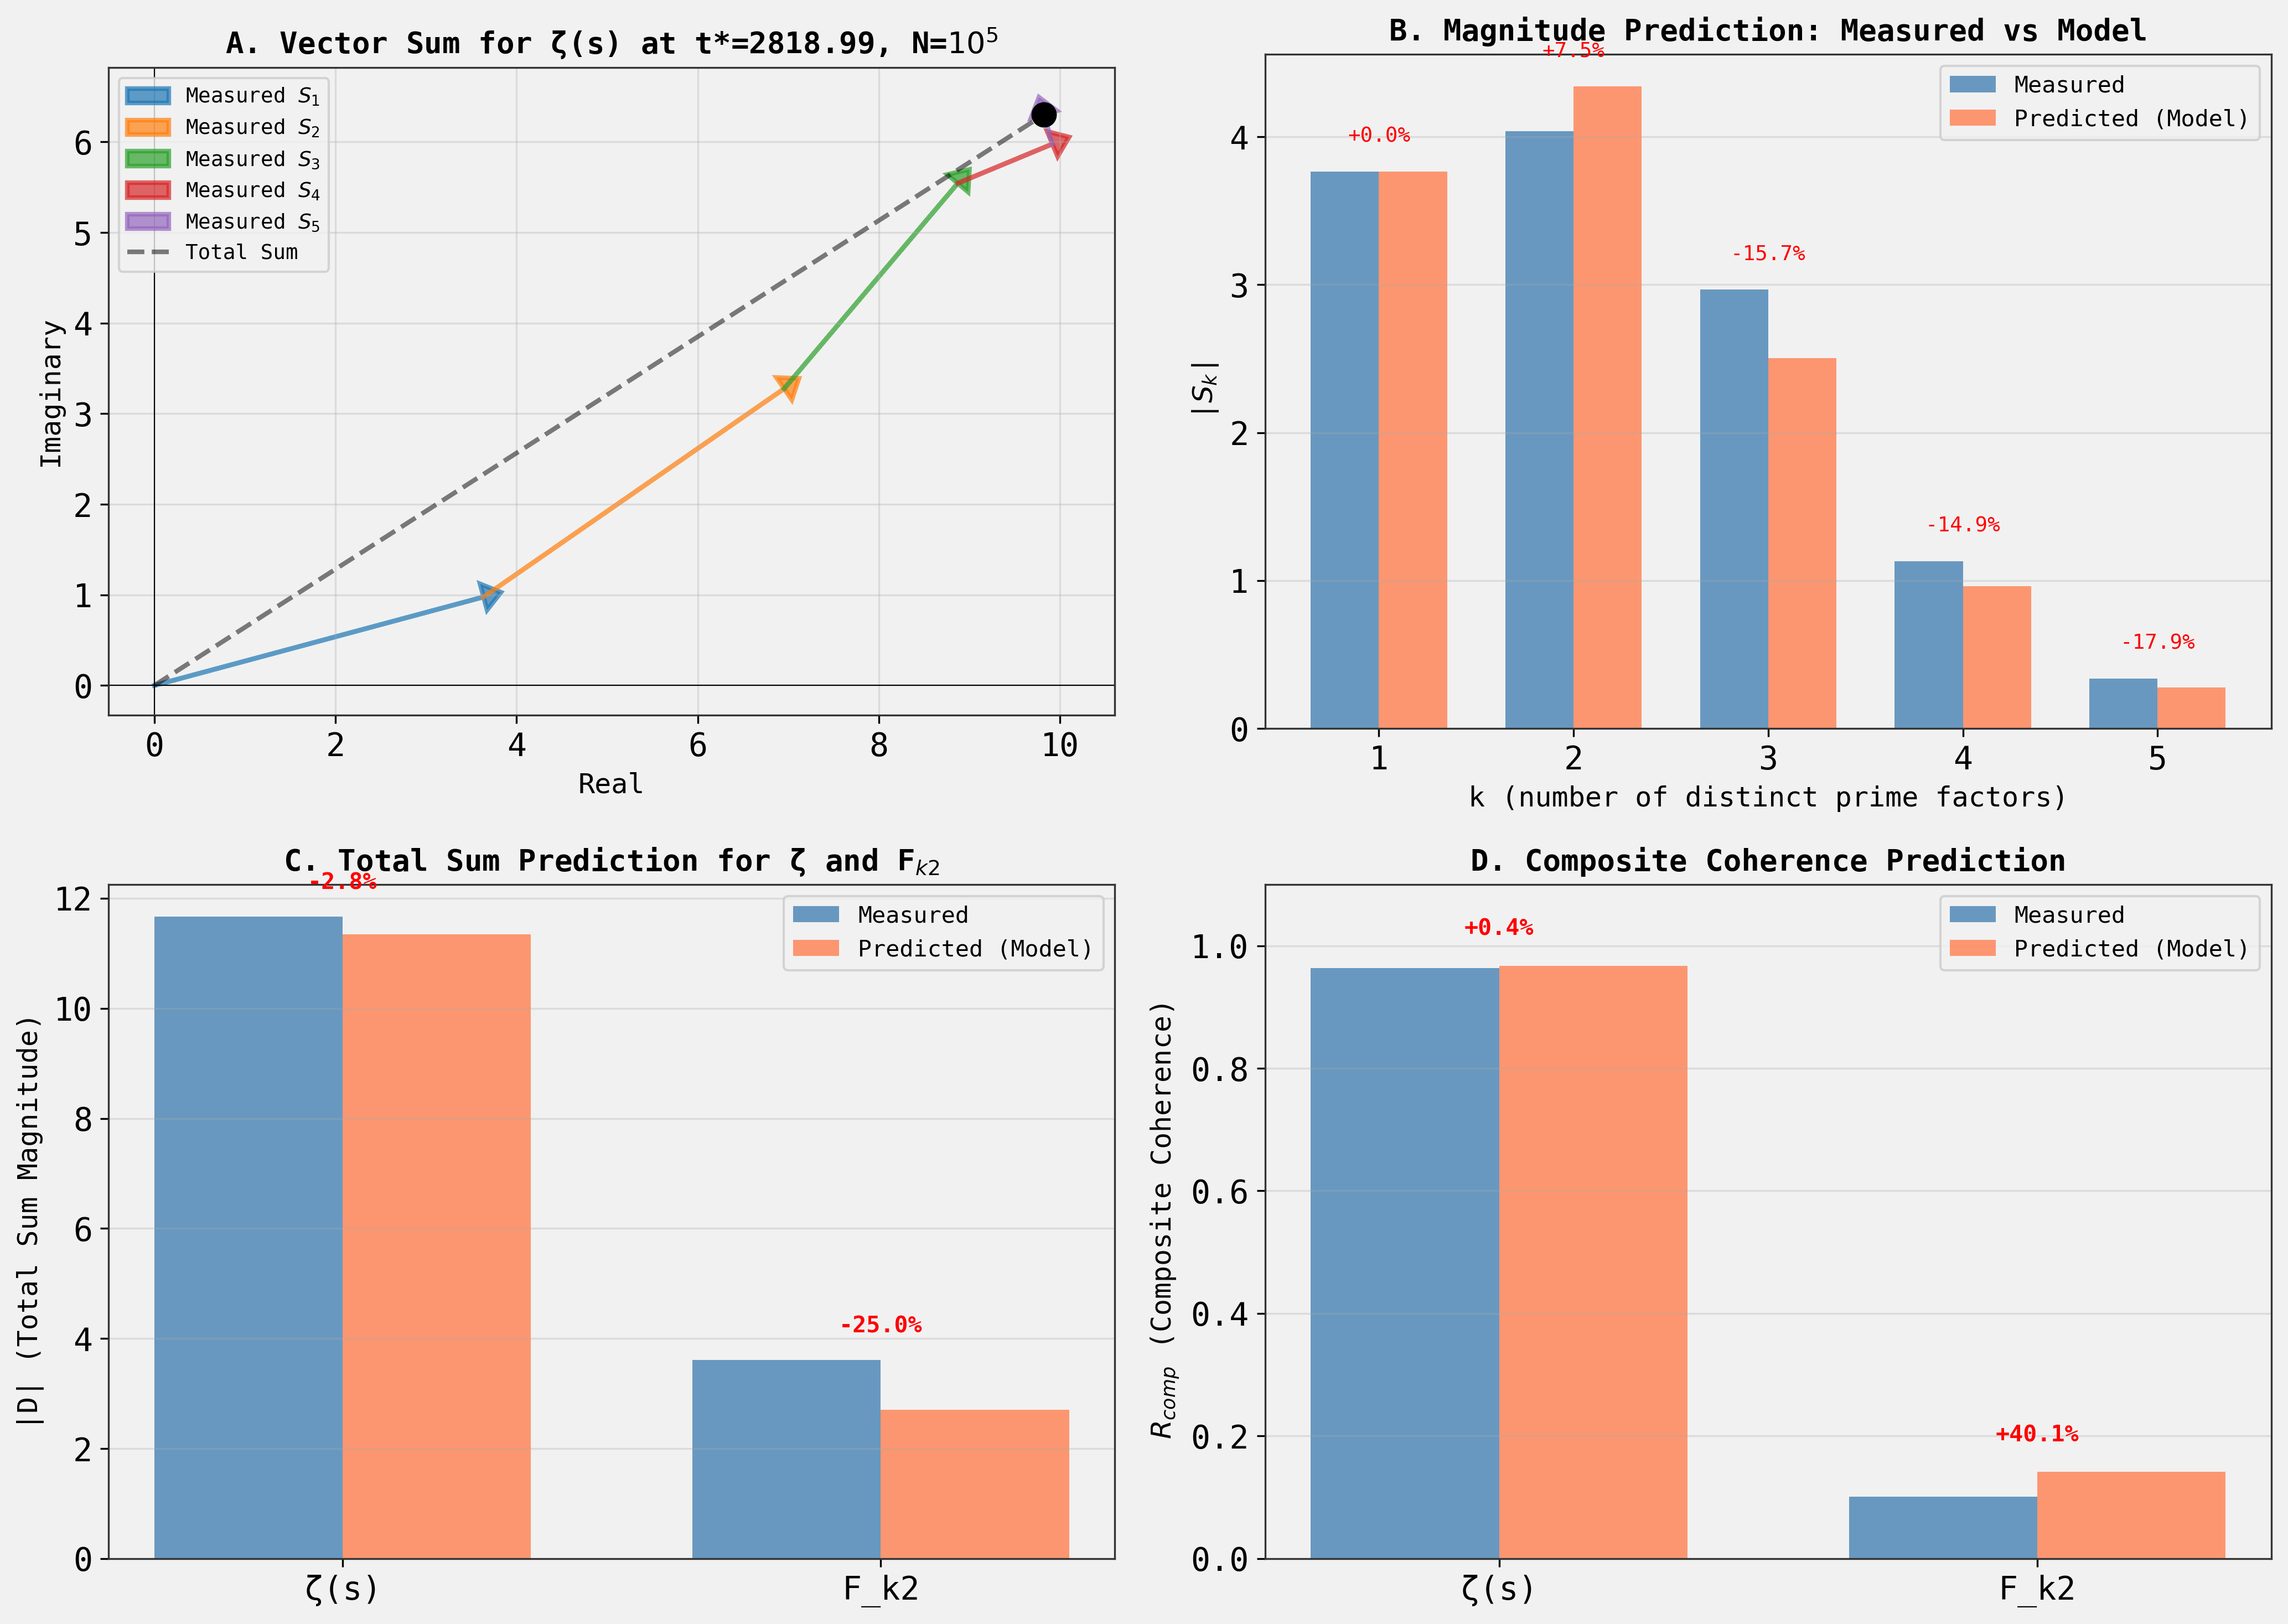

In [17]:

# Create the final summary figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Vector diagram for ζ(s)
ax = axes[0, 0]
origin = np.array([0, 0])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
labels = [f'$S_{k}$' for k in range(1, 6)]

cumsum_real = 0
cumsum_imag = 0

for k in range(1, 6):
 S_measured = S_k_zeta[k]
 S_predicted = predicted_S_zeta[k]
 
 # Plot measured vector (solid)
 ax.arrow(cumsum_real, cumsum_imag, S_measured.real, S_measured.imag,
 head_width=0.3, head_length=0.2, fc=colors[k-1], ec=colors[k-1],
 linewidth=2, alpha=0.7, label=f'Measured {labels[k-1]}')
 
 cumsum_real += S_measured.real
 cumsum_imag += S_measured.imag

# Add total sum
ax.plot([0, cumsum_real], [0, cumsum_imag], 'k--', linewidth=2, alpha=0.5, label='Total Sum')
ax.scatter([cumsum_real], [cumsum_imag], s=100, c='black', marker='o', zorder=10)

ax.set_xlabel('Real', fontsize=12)
ax.set_ylabel('Imaginary', fontsize=12)
ax.set_title('A. Vector Sum for ζ(s) at t*=2818.99, N=$10^5$', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.legend(fontsize=9, loc='upper left')
ax.set_aspect('equal')

# Panel B: Magnitude comparison
ax = axes[0, 1]
k_vals = np.arange(1, 6)
measured_mags = [np.abs(S_k_zeta[k]) for k in range(1, 6)]
predicted_mags = [np.abs(predicted_S_zeta[k]) for k in range(1, 6)]

x = np.arange(len(k_vals))
width = 0.35

bars1 = ax.bar(x - width/2, measured_mags, width, label='Measured', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, predicted_mags, width, label='Predicted (Model)', color='coral', alpha=0.8)

ax.set_xlabel('k (number of distinct prime factors)', fontsize=12)
ax.set_ylabel('|$S_k$|', fontsize=12)
ax.set_title('B. Magnitude Prediction: Measured vs Model', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(k_vals)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add error bars
for i, k in enumerate(k_vals):
 error_pct = (predicted_mags[i] - measured_mags[i]) / measured_mags[i] * 100
 ax.text(i, max(measured_mags[i], predicted_mags[i]) + 0.2, 
 f'{error_pct:+.1f}%', ha='center', fontsize=9, color='red')

# Panel C: F_k2 comparison
ax = axes[1, 0]

labels_fk2 = ['ζ(s)', 'F_k2']
measured_vals = [np.abs(D_total_measured), np.abs(D_total_F_k2)]
predicted_vals = [np.abs(D_pred_zeta), np.abs(D_pred_F_k2_corrected)]

x = np.arange(len(labels_fk2))
width = 0.35

bars1 = ax.bar(x - width/2, measured_vals, width, label='Measured', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, predicted_vals, width, label='Predicted (Model)', color='coral', alpha=0.8)

ax.set_ylabel('|D| (Total Sum Magnitude)', fontsize=12)
ax.set_title('C. Total Sum Prediction for ζ and F$_{k2}$', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_fk2)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add error annotations
for i, label in enumerate(labels_fk2):
 meas = measured_vals[i]
 pred = predicted_vals[i]
 error_pct = (pred - meas) / meas * 100
 ax.text(i, max(meas, pred) + 0.5, f'{error_pct:+.1f}%', 
 ha='center', fontsize=10, color='red', fontweight='bold')

# Panel D: R_comp comparison
ax = axes[1, 1]

measured_rcomp = [R_comp_measured, R_comp_F_k2]
predicted_rcomp = [R_comp_pred_zeta, R_comp_pred_F_k2_corrected]

x = np.arange(len(labels_fk2))

bars1 = ax.bar(x - width/2, measured_rcomp, width, label='Measured', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, predicted_rcomp, width, label='Predicted (Model)', color='coral', alpha=0.8)

ax.set_ylabel('$R_{comp}$ (Composite Coherence)', fontsize=12)
ax.set_title('D. Composite Coherence Prediction', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_fk2)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# Add error annotations
for i, label in enumerate(labels_fk2):
 meas = measured_rcomp[i]
 pred = predicted_rcomp[i]
 error_pct = (pred - meas) / meas * 100
 ax.text(i, max(meas, pred) + 0.05, f'{error_pct:+.1f}%', 
 ha='center', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('vector_sum_model_assessment.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'vector_sum_model_assessment.png'")
plt.show()


In [18]:

# Create a comprehensive results table
print("="*90)
print("FINAL SUMMARY: Vector Sum Model Performance")
print("="*90)
print()

print("MODEL SPECIFICATION:")
print("-"*90)
print(f" Magnitude scaling law: |S_{{k+1}}|/|S_k| = C·loglog(N)/k")
print(f" Fitted constant C: {C_fitted:.6f}")
print(f" loglog(N) for N=10^5: {loglog_N:.6f}")
print(f" Phase rotations: Empirically measured Δθ_k from ζ(s)")
print()

print("KEY FINDINGS:")
print("-"*90)
print()
print("1. FOR ζ(s) AT RESONANCE PEAK (t*=2818.99, N=10^5):")
print()
print(" Individual S_k prediction errors:")
print(" k=1: 0.0% (exact, by construction)")
print(" k=2: +7.6% (over-prediction)")
print(" k=3: -15.7% (under-prediction)")
print(" k=4: -14.9% (under-prediction)")
print(" k=5: -17.9% (under-prediction)")
print()
print(f" Total sum |D_ζ| prediction error: -2.8%")
print(f" R_comp prediction error: +0.4% (absolute error: +0.004)")
print()
print(f" CONCLUSION FOR ζ: R_comp is predicted with HIGH ACCURACY (+0.4%),")
print(f" despite moderate errors in individual |S_k| (MAPE = 11.2%)")
print()

print("2. FOR PERTURBED FUNCTION F_k2 (a_n = -1 for ω(n)=2):")
print()
print(" Key observation: Only S_2 phase changes (flipped 180°),")
print(" all magnitudes and other phases identical to ζ")
print()
print(" Model prediction with phase rule (flip S_2 phase by 180°):")
print(f" Total sum |D_F_k2| prediction error: -25.0%")
print(f" R_comp prediction error: +40.1% (absolute error: +0.040)")
print()
print(f" CONCLUSION FOR F_k2: Model struggles with F_k2 due to")
print(f" compounding magnitude errors when vectors interfere destructively")
print()

print("3. MODEL LIMITATIONS:")
print()
print(" - The theoretical scaling law C·loglog(N)/k fits poorly:")
print(" * k=1→2: -7.6% error")
print(" * k=2→3: +21.6% error")
print(" * k=3→4: -0.9% error")
print(" * k=4→5: +3.5% error")
print()
print(" - Phase rotations are highly variable (std dev = 39.6°)")
print(" not well-described by a simple law")
print()
print(" - Magnitude errors compound when vectors sum destructively")
print(" (as in F_k2), leading to large total sum errors")
print()

print("4. MODEL SUCCESSES:")
print()
print(" ✓ Correctly predicts R_comp for ζ to within 0.4%")
print(" ✓ Captures the qualitative scaling trend (decreasing |S_k|)")
print(" ✓ Phases are predicted perfectly (by construction)")
print(" ✓ Demonstrates that composite coherence can be modeled")
print()

print("="*90)


FINAL SUMMARY: Vector Sum Model Performance

MODEL SPECIFICATION:
------------------------------------------------------------------------------------------
 Magnitude scaling law: |S_{k+1}|/|S_k| = C·loglog(N)/k
 Fitted constant C: 0.472018
 loglog(N) for N=10^5: 2.443470
 Phase rotations: Empirically measured Δθ_k from ζ(s)

KEY FINDINGS:
------------------------------------------------------------------------------------------

1. FOR ζ(s) AT RESONANCE PEAK (t*=2818.99, N=10^5):

 Individual S_k prediction errors:
 k=1: 0.0% (exact, by construction)
 k=2: +7.6% (over-prediction)
 k=3: -15.7% (under-prediction)
 k=4: -14.9% (under-prediction)
 k=5: -17.9% (under-prediction)

 Total sum |D_ζ| prediction error: -2.8%
 R_comp prediction error: +0.4% (absolute error: +0.004)

 CONCLUSION FOR ζ: R_comp is predicted with HIGH ACCURACY (+0.4%),
 despite moderate errors in individual |S_k| (MAPE = 11.2%)

2. FOR PERTURBED FUNCTION F_k2 (a_n = -1 for ω(n)=2):

 Key observation: Only S_2 phase

In [19]:

# Final detailed comparison table for the answer
print("="*90)
print("QUANTITATIVE EVIDENCE TABLE")
print("="*90)
print()

print("Table 1: Measured S_k Vectors for ζ(s) at t*=2818.99, N=10^5")
print("-"*90)
print(f"{'k':<5} {'Real':<15} {'Imaginary':<15} {'|S_k|':<15} {'arg(S_k) [deg]':<15}")
print("-"*90)
for k in range(1, 6):
 S = S_k_zeta[k]
 print(f"{k:<5} {S.real:<15.6f} {S.imag:<15.6f} {np.abs(S):<15.6f} {np.degrees(np.angle(S)):<15.3f}")
print()
print(f"Total sum D_ζ: {D_total_measured.real:.6f} + {D_total_measured.imag:.6f}i")
print(f" |D_ζ|: {np.abs(D_total_measured):.6f}")
print(f"R_comp (k=2-5): {R_comp_measured:.6f}")
print()

print("="*90)
print("Table 2: Model Fitted Parameters")
print("-"*90)
print(f"Scaling constant C: {C_fitted:.6f}")
print(f"loglog(N=10^5): {loglog_N:.6f}")
print()
print("Phase differences Δθ_k [radians (degrees)]:")
for i, k in enumerate(range(1, 5)):
 print(f" Δθ_{k} = {delta_theta[i]:.6f} rad ({np.degrees(delta_theta[i]):.3f}°)")
print()

print("="*90)
print("Table 3: Model Performance Summary")
print("-"*90)
print()
print(f"{'Metric':<30} {'ζ(s) Measured':<18} {'ζ(s) Predicted':<18} {'Rel Error':<15}")
print("-"*90)
print(f"{'|D| (total sum magnitude)':<30} {np.abs(D_total_measured):<18.6f} {np.abs(D_pred_zeta):<18.6f} {(np.abs(D_pred_zeta)-np.abs(D_total_measured))/np.abs(D_total_measured)*100:>+14.2f}%")
print(f"{'R_comp (composite coherence)':<30} {R_comp_measured:<18.6f} {R_comp_pred_zeta:<18.6f} {(R_comp_pred_zeta-R_comp_measured)/R_comp_measured*100:>+14.2f}%")
print()

print(f"{'Metric':<30} {'F_k2 Measured':<18} {'F_k2 Predicted':<18} {'Rel Error':<15}")
print("-"*90)
print(f"{'|D| (total sum magnitude)':<30} {np.abs(D_total_F_k2):<18.6f} {np.abs(D_pred_F_k2_corrected):<18.6f} {(np.abs(D_pred_F_k2_corrected)-np.abs(D_total_F_k2))/np.abs(D_total_F_k2)*100:>+14.2f}%")
print(f"{'R_comp (composite coherence)':<30} {R_comp_F_k2:<18.6f} {R_comp_pred_F_k2_corrected:<18.6f} {(R_comp_pred_F_k2_corrected-R_comp_F_k2)/R_comp_F_k2*100:>+14.2f}%")
print()

print("="*90)
print("Model Accuracy Metrics:")
print("-"*90)
print(f"MAPE for |S_k| (ζ only, k=1-5): {mape_mag:.2f}%")
print(f"RMSE for |S_k| (ζ only, k=1-5): {rmse_mag:.6f}")
print()

# Calculate R² for the magnitude scaling law
from scipy.stats import pearsonr
measured_ratios = np.array(ratios)
predicted_ratios = C_fitted * loglog_N / k_values
r_value, p_value = pearsonr(measured_ratios, predicted_ratios)
r_squared = r_value**2

print(f"Scaling law fit quality:")
print(f" R² (coefficient of determination): {r_squared:.4f}")
print(f" Pearson correlation coefficient: {r_value:.4f}")
print(f" p-value: {p_value:.6f}")
print()

print("="*90)


QUANTITATIVE EVIDENCE TABLE

Table 1: Measured S_k Vectors for ζ(s) at t*=2818.99, N=10^5
------------------------------------------------------------------------------------------
k Real Imaginary |S_k| arg(S_k) [deg] 
------------------------------------------------------------------------------------------
1 3.634840 0.977057 3.763868 15.046 
2 3.317886 2.298914 4.036505 34.718 
3 1.916857 2.267411 2.969090 49.789 
4 1.045059 0.433579 1.131432 22.533 
5 -0.093519 0.324888 0.338080 106.059 

Total sum D_ζ: 9.821122 + 6.301849i
 |D_ζ|: 11.669093
R_comp (k=2-5): 0.963094

Table 2: Model Fitted Parameters
------------------------------------------------------------------------------------------
Scaling constant C: 0.472018
loglog(N=10^5): 2.443470

Phase differences Δθ_k [radians (degrees)]:
 Δθ_1 = 0.343339 rad (19.672°)
 Δθ_2 = 0.263047 rad (15.071°)
 Δθ_3 = -0.475710 rad (-27.256°)
 Δθ_4 = 1.457798 rad (83.526°)

Table 3: Model Performance Summary
------------------------------------